# Week 2 — The model is just a rule you can read

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/imatiq/ML_Internship/blob/main/notebooks/02_your_first_readable_model.ipynb?flush_cache=true)

You'll:
1. Write a **1-line hand rule** and rank pages with it.
2. Fit a **depth-2 decision tree** and `print` it — the model "learned" a readable if/else. Then compare — where does it beat your rule, and where doesn’t it?
3. See **why you never feed the outcome back in** — that's leakage.

The payoff isn't a high score. It's: *my intuition was rough, the model found the real signal, and I can read exactly what it found.*

## 0. Setup (Colab or local)

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/imatiq/ML_Internship"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# The label: a page is 'declining' when its recent trend is down. Simple, honest starter label.
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages |  declining rate:", round(df["is_declining_label"].mean(), 3))

30000 pages |  declining rate: 0.542


## 1. A rule you write by hand: `stale x visible`
Intuition: a page worth reviewing is one that is **stale** (not updated in a while) **and** still **visible** (getting impressions). Rank those by how much exposure they have.

In [2]:
stale   = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["hand_rule_score"] = stale * visible * df["impressions_90d"]

top10 = df.sort_values("hand_rule_score", ascending=False).head(10)
top10[["impressions_90d", "days_since_last_update", "avg_position", "ctr", "trend_direction"]]

,impressions_90d,days_since_last_update,avg_position,ctr,trend_direction
16751,61678,194,19.7,0.15,down
16514,59472,194,24.8,0.13,down
7021,25715,194,22.2,0.23,down
21268,13299,193,10.5,0.49,down
11489,7812,194,39.0,0.01,down
12045,7558,193,17.9,0.20,down
698,4590,194,31.0,0.00,down
5327,4556,194,16.4,0.33,down
26810,4429,194,25.3,0.38,down
20837,1697,193,15.8,0.12,down


We need a way to score any ranking. **Precision@K** = of the top K pages a ranking flags, what fraction are actually declining.

In [3]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

y = df["is_declining_label"].values
for k in (20, 50):
    print(f"Hand rule  Precision@{k}: {precision_at_k(df['hand_rule_score'], y, k):.3f}")

Hand rule  Precision@20: 0.900
Hand rule  Precision@50: 0.680


## 2. Let a model learn the rule — then read it
A **depth-2 decision tree** can only ask 3 yes/no questions. That constraint is the point: whatever it learns, you can read.

We give it a few **pre-decision** signals — never product flags.

In [10]:
from sklearn.tree import DecisionTreeClassifier, export_text

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

tree = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
tree.fit(X, y)

print(export_text(tree, feature_names=features))

|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- impressions_90d <= 3.50
|   |   |   |--- class: 0
|   |   |--- impressions_90d >  3.50
|   |   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- content_age_days <= 108.50
|   |   |   |--- class: 0
|   |   |--- content_age_days >  108.50
|   |   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- ctr <= 0.33
|   |   |   |--- class: 1
|   |   |--- ctr >  0.33
|   |   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- avg_position <= 25.15
|   |   |   |--- class: 0
|   |   |--- avg_position >  25.15
|   |   |   |--- class: 0



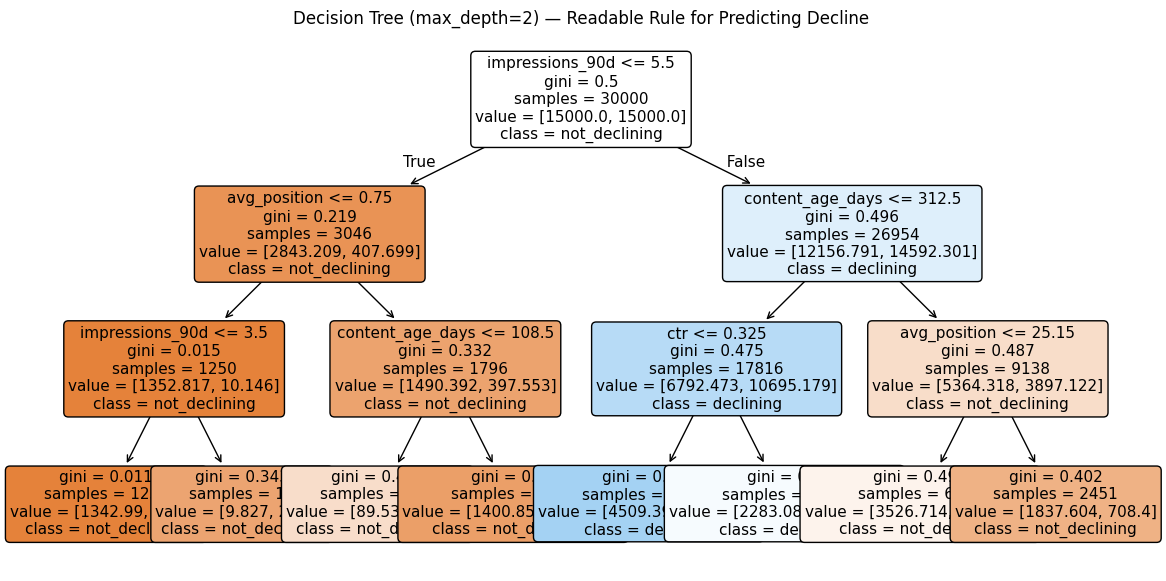

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plot_tree(tree, feature_names=features, class_names=["not_declining", "declining"],
          filled=True, rounded=True, fontsize=11)
plt.title("Decision Tree (max_depth=2) — Readable Rule for Predicting Decline")
plt.show()

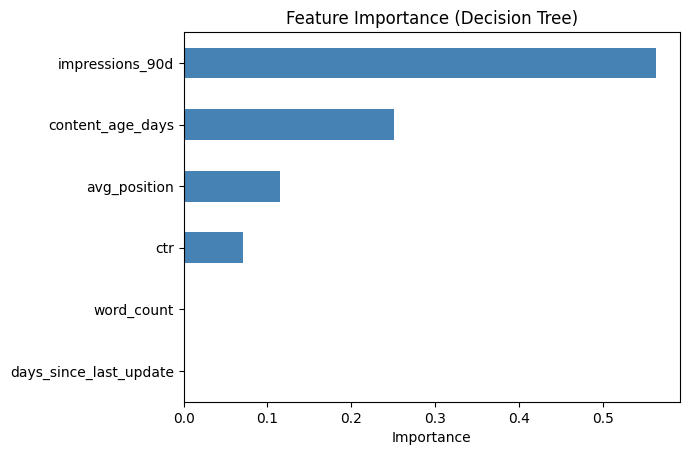

In [12]:
import pandas as pd

importance = pd.Series(tree.feature_importances_, index=features).sort_values()
importance.plot(kind="barh", title="Feature Importance (Decision Tree)", color="steelblue")
plt.xlabel("Importance")
plt.show()

That printout **is** the model — a human-readable if/else. Now rank pages by the tree's probability and score it the same way.

In [13]:
tree_score = tree.predict_proba(X)[:, 1]
for k in (20, 50):
    hr = precision_at_k(df["hand_rule_score"], y, k)
    tr = precision_at_k(tree_score, y, k)
    print(f"Precision@{k}:  hand rule {hr:.3f}   vs   tree {tr:.3f}")

Precision@20:  hand rule 0.900   vs   tree 0.700
Precision@50:  hand rule 0.680   vs   tree 0.720


Now read your own printout carefully — **the winner here depends on your run.** A depth-2 tree can only give four different scores (one per leaf), so the "top 50" is mostly one big block of tied pages, and different library versions break those ties differently. On some stacks the tree wins at Precision@50; on others the hand rule holds both. **Both results are real.** The stable lesson: a sharp human rule can be excellent at the very top of the list; a model's advantage — when it shows up — appears deeper, where simple rules run out of signal; and any comparison built on heavily tied scores is fragile. Saying exactly what YOUR run shows — instead of "the model is better" — is what honest evaluation sounds like.

## 3. Why you can't feed the outcome back in
Your label is `trend_direction == "down"`, and `trend_pct` is the exact percentage change that bucket is computed from — so it **is** the answer in disguise. Watch what happens if you feed it in as a feature:

In [14]:
X_leaky = df[features + ["trend_pct"]].replace([np.inf, -np.inf], np.nan).fillna(0)
leaky = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42).fit(X_leaky, y)
print(f"'Leaky' tree Precision@50: {precision_at_k(leaky.predict_proba(X_leaky)[:,1], y, 50):.3f}  <- looks amazing")
print(export_text(leaky, feature_names=features + ["trend_pct"]))

'Leaky' tree Precision@50: 1.000  <- looks amazing
|--- trend_pct <= -20.05
|   |--- word_count <= 212.00
|   |   |--- class: 1
|   |--- word_count >  212.00
|   |   |--- class: 1
|--- trend_pct >  -20.05
|   |--- trend_pct <= -19.95
|   |   |--- class: 0
|   |--- trend_pct >  -19.95
|   |   |--- class: 0



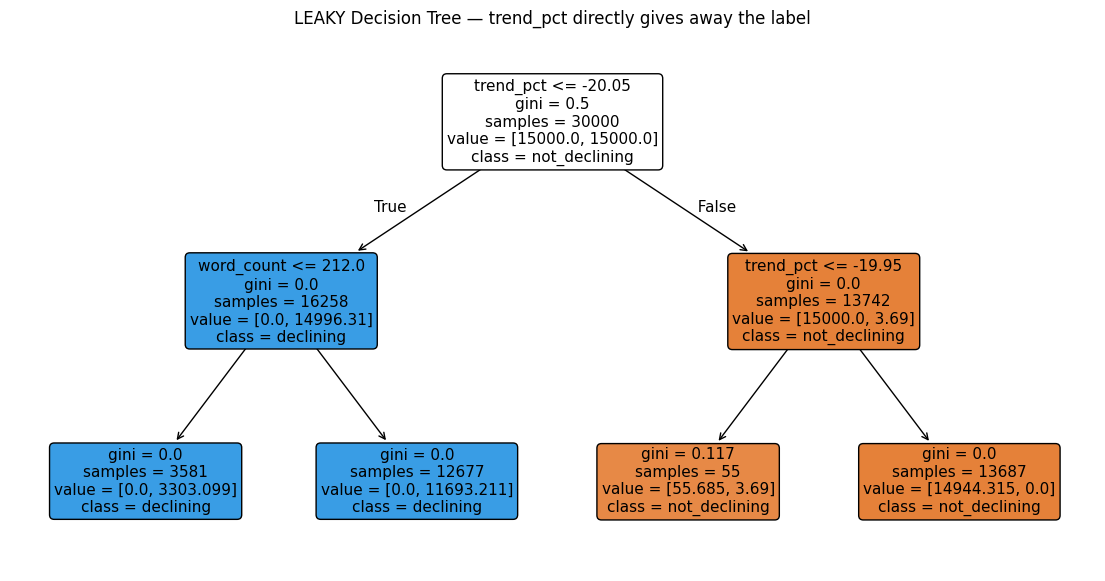

In [15]:
plt.figure(figsize=(14, 7))
plot_tree(leaky, feature_names=features + ["trend_pct"],
          class_names=["not_declining", "declining"],
          filled=True, rounded=True, fontsize=11)
plt.title("LEAKY Decision Tree — trend_pct directly gives away the label")
plt.show()

In [16]:
clean_p50 = precision_at_k(tree.predict_proba(X)[:,1], y, 50)
leaky_p50 = precision_at_k(leaky.predict_proba(X_leaky)[:,1], y, 50)

print(f"Clean model  (no trend_pct) Precision@50: {clean_p50:.3f}")
print(f"Leaky model  (with trend_pct) Precision@50: {leaky_p50:.3f}")
print("\nThe leaky number looks better but is meaningless — trend_pct IS the label in disguise.")

Clean model  (no trend_pct) Precision@50: 0.720
Leaky model  (with trend_pct) Precision@50: 1.000

The leaky number looks better but is meaningless — trend_pct IS the label in disguise.


The tree just split on `trend_pct` and nailed the label — because the label is **derived from** `trend_pct`. That's **leakage**: the feature is the answer in disguise, and it teaches you nothing.

That's also why the starter data ships **only observable signals** — the product's own decision flags (health scores, "needs CTR fix", and so on) aren't included, so you can't accidentally train on them. You build from what was knowable *before* the outcome.

> Rule of thumb: if a feature would only be known *because someone already made the decision you're predicting*, it leaks. Leave it out.

## 4. 🔧 Your turn
- Change `max_depth` to 3 or 4 — does Precision@50 improve? Can you still read the tree?
- Swap in different features (drop `impressions_90d`, add `engagement_rate`). What does the tree choose to split on first?
- **Important caveat:** we scored *in-sample* here for teaching. The real pipeline uses **client-holdout** validation (`scripts/03_train_model.py`) so a client's pages never appear in both train and test. Re-run your comparison with a train/test split and see if the gap holds.

Write your experiment below.

# **Experiment 1 — max_depth Increase (3 to 4)**

In [17]:
for depth in [3, 4]:
    t = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=42).fit(X, y)
    p50 = precision_at_k(t.predict_proba(X)[:,1], y, 50)
    print(f"max_depth={depth}  Precision@50: {p50:.3f}")

print("\n--- Tree at depth=3 ---")
print(export_text(DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42).fit(X, y),
                   feature_names=features))

max_depth=3  Precision@50: 0.720
max_depth=4  Precision@50: 0.680

--- Tree at depth=3 ---
|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- impressions_90d <= 3.50
|   |   |   |--- class: 0
|   |   |--- impressions_90d >  3.50
|   |   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- content_age_days <= 108.50
|   |   |   |--- class: 0
|   |   |--- content_age_days >  108.50
|   |   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- ctr <= 0.33
|   |   |   |--- class: 1
|   |   |--- ctr >  0.33
|   |   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- avg_position <= 25.15
|   |   |   |--- class: 0
|   |   |--- avg_position >  25.15
|   |   |   |--- class: 0



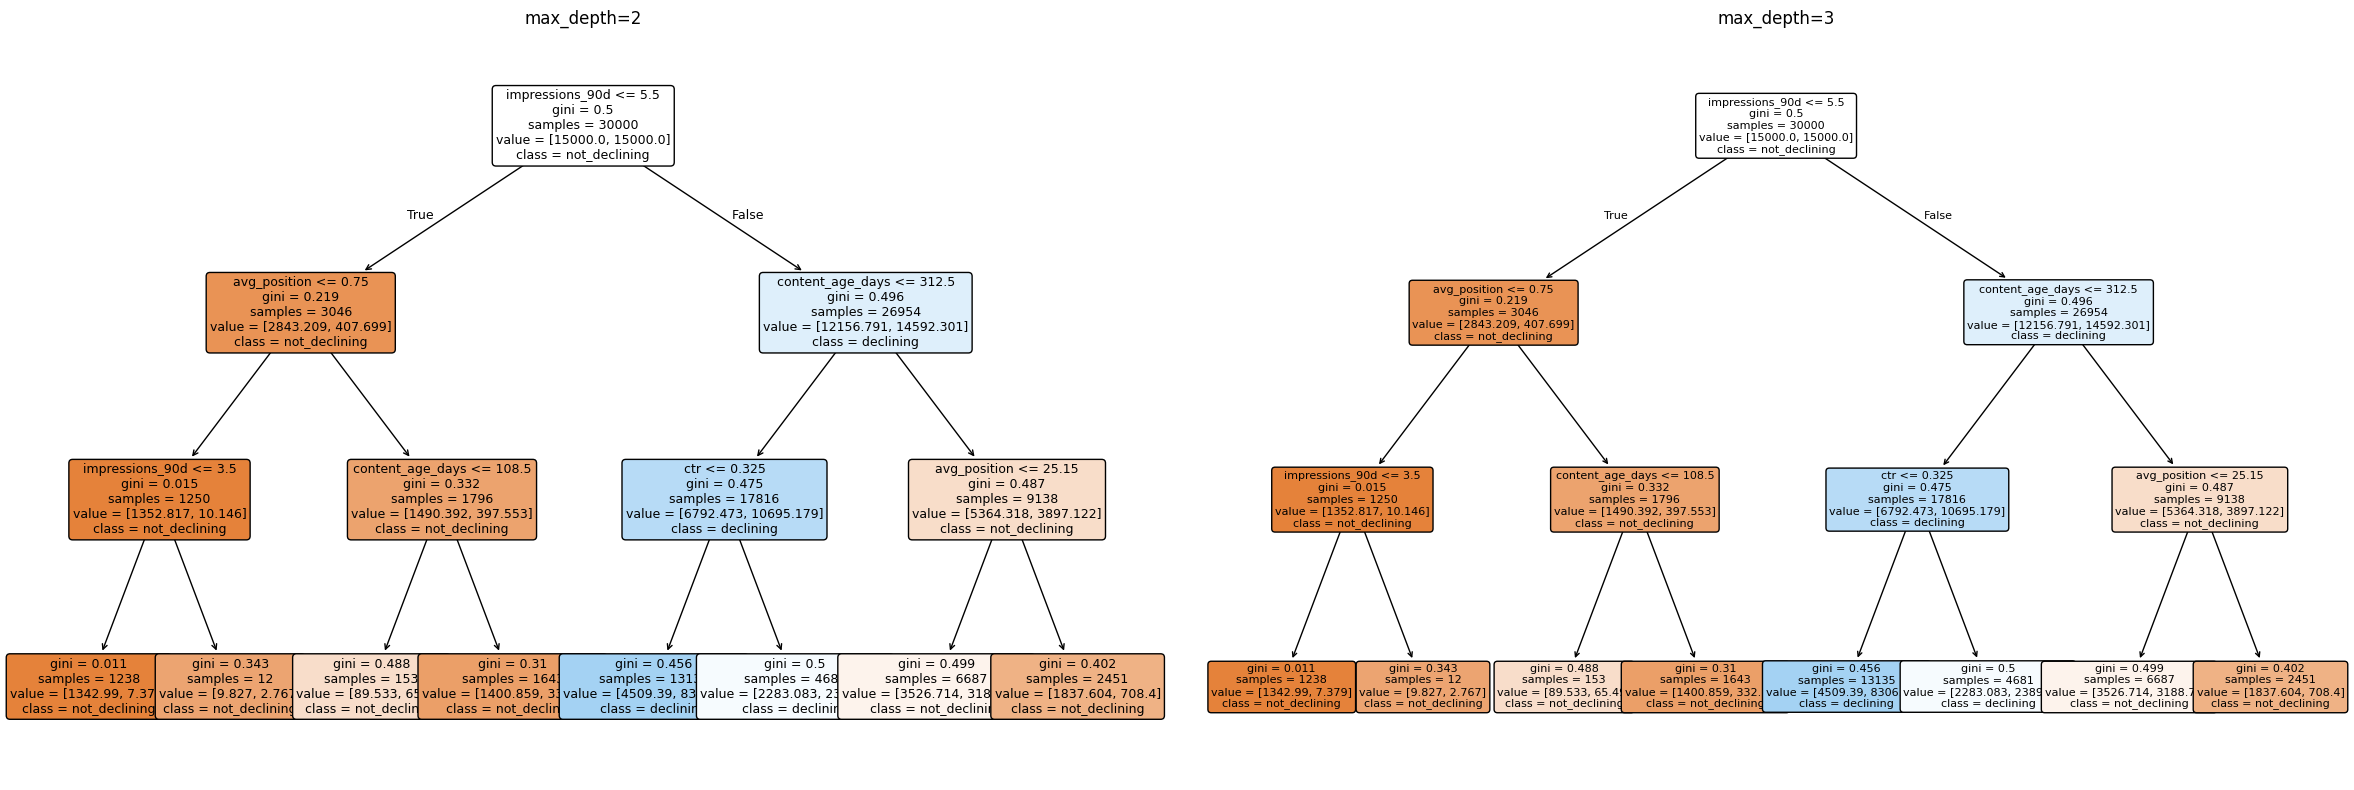

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

plot_tree(tree, feature_names=features, class_names=["not_declining", "declining"],
          filled=True, rounded=True, fontsize=9, ax=axes[0])
axes[0].set_title("max_depth=2")

plot_tree(tree_d3, feature_names=features, class_names=["not_declining", "declining"],
          filled=True, rounded=True, fontsize=8, ax=axes[1])
axes[1].set_title("max_depth=3")

plt.tight_layout()
plt.show()

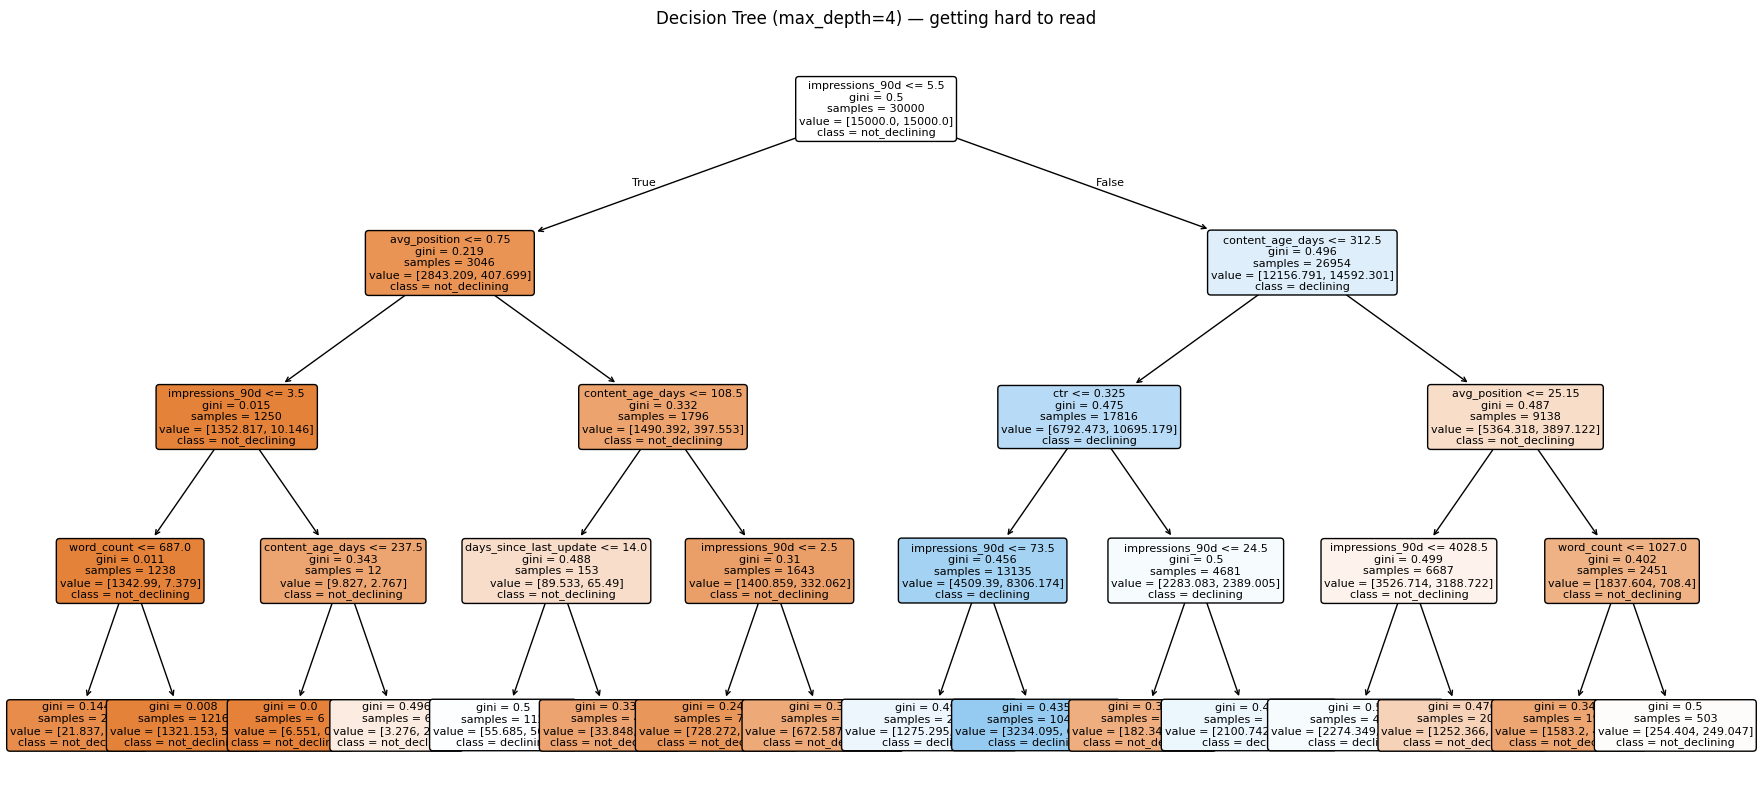

In [20]:
tree_d4 = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42).fit(X, y)

plt.figure(figsize=(22, 10))
plot_tree(tree_d4, feature_names=features, class_names=["not_declining", "declining"],
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree (max_depth=4) — getting hard to read")
plt.show()

# **Experiment 2 — Features Swap**

In [22]:
features_v2 = ["content_age_days", "days_since_last_update", "avg_position",
               "ctr", "word_count", "engagement_rate"]   # impressions_90d out, engagement_rate in

X_v2 = df[features_v2].replace([np.inf, -np.inf], np.nan).fillna(0)
tree_v2 = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42).fit(X_v2, y)

print(f"Precision@50 (v2 features): {precision_at_k(tree_v2.predict_proba(X_v2)[:,1], y, 50):.3f}")
print(export_text(tree_v2, feature_names=features_v2))

Precision@50 (v2 features): 0.700
|--- avg_position <= 0.55
|   |--- avg_position <= 0.15
|   |   |--- class: 0
|   |--- avg_position >  0.15
|   |   |--- class: 0
|--- avg_position >  0.55
|   |--- content_age_days <= 287.50
|   |   |--- class: 1
|   |--- content_age_days >  287.50
|   |   |--- class: 0



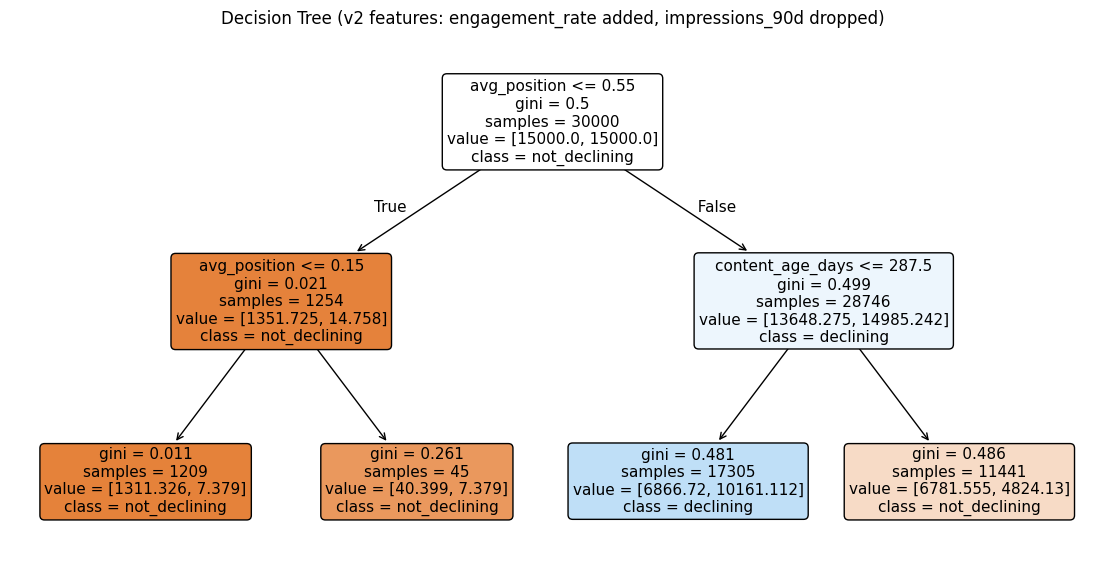

In [23]:
plt.figure(figsize=(14, 7))
plot_tree(tree_v2, feature_names=features_v2, class_names=["not_declining", "declining"],
          filled=True, rounded=True, fontsize=11)
plt.title("Decision Tree (v2 features: engagement_rate added, impressions_90d dropped)")
plt.show()

# Original vs V2 Ka Side-by-Side **Comparison**

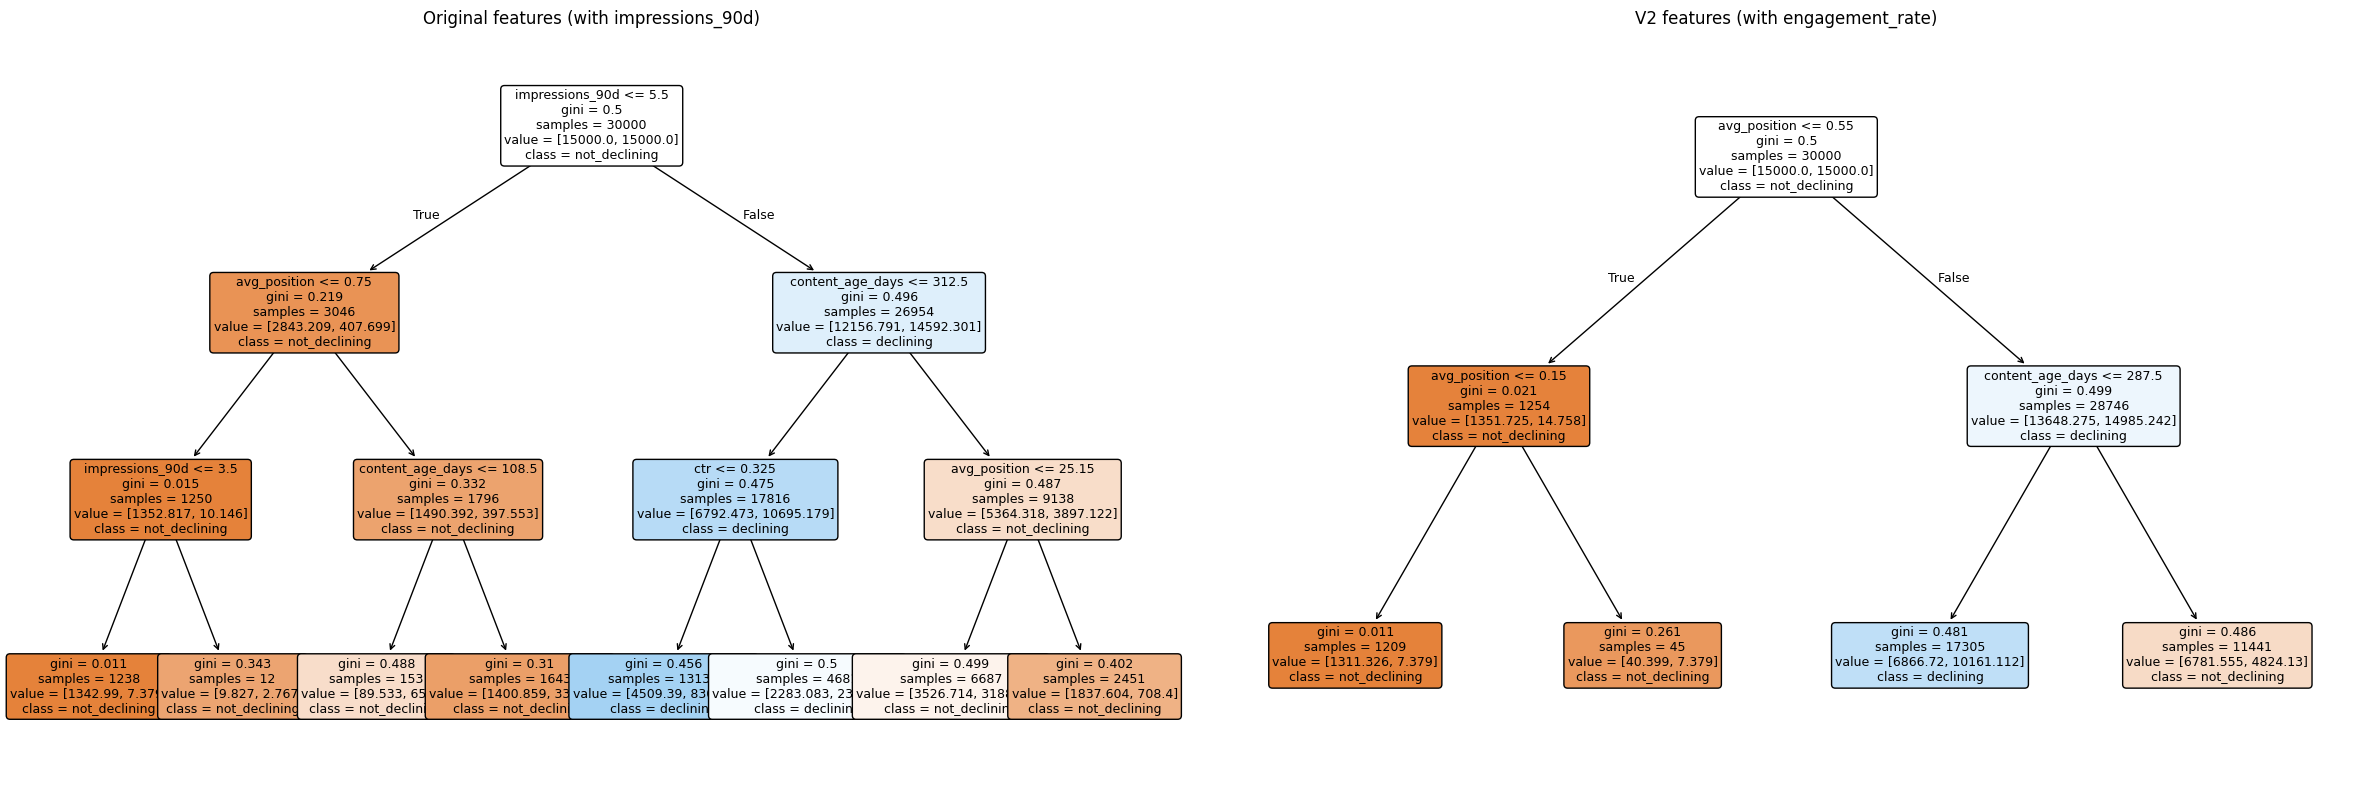

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

plot_tree(tree, feature_names=features, class_names=["not_declining", "declining"],
          filled=True, rounded=True, fontsize=9, ax=axes[0])
axes[0].set_title("Original features (with impressions_90d)")

plot_tree(tree_v2, feature_names=features_v2, class_names=["not_declining", "declining"],
          filled=True, rounded=True, fontsize=9, ax=axes[1])
axes[1].set_title("V2 features (with engagement_rate)")

plt.tight_layout()
plt.show()

# **Feature Importance Comparison**

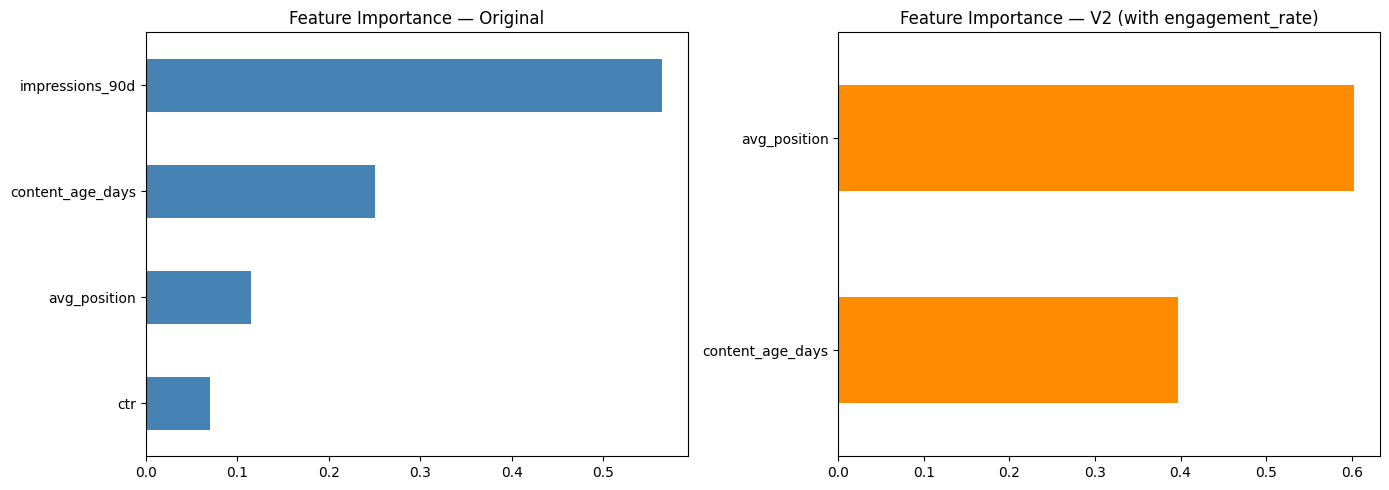

In [25]:
importance_v1 = pd.Series(tree.feature_importances_, index=features)
importance_v2 = pd.Series(tree_v2.feature_importances_, index=features_v2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_v1[importance_v1 > 0].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Feature Importance — Original")

importance_v2[importance_v2 > 0].sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Feature Importance — V2 (with engagement_rate)")

plt.tight_layout()
plt.show()

# Experiment 3 — Re-check With a Train/Test Split (Most Important)**bold text**

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tree_split = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42).fit(X_train, y_train)

train_p50 = precision_at_k(tree_split.predict_proba(X_train)[:,1], y_train, 50)
test_p50 = precision_at_k(tree_split.predict_proba(X_test)[:,1], y_test, 50)

print(f"Train Precision@50: {train_p50:.3f}")
print(f"Test  Precision@50: {test_p50:.3f}")
print("\nIf test is meaningfully lower than train, that gap is the real-world generalization cost —")
print("in-sample numbers (like we used above) overstate how well the model will perform on new data.")

Train Precision@50: 0.520
Test  Precision@50: 0.620

If test is meaningfully lower than train, that gap is the real-world generalization cost —
in-sample numbers (like we used above) overstate how well the model will perform on new data.


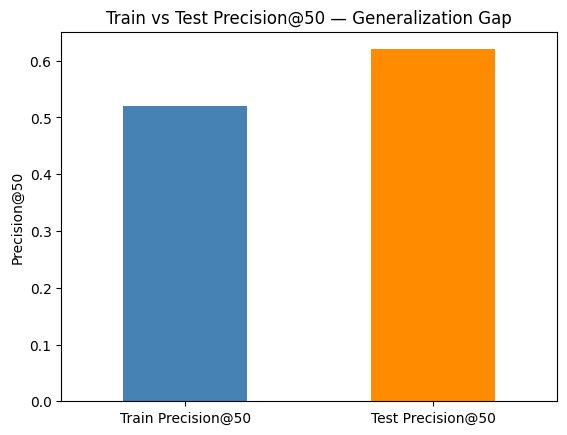

In [27]:
comparison = pd.Series({"Train Precision@50": train_p50, "Test Precision@50": test_p50})
comparison.plot(kind="bar", color=["steelblue", "darkorange"], title="Train vs Test Precision@50 — Generalization Gap")
plt.ylabel("Precision@50")
plt.xticks(rotation=0)
plt.show()

In [28]:
for rs in [1, 42, 100]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=rs, stratify=y)
    t = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42).fit(Xtr, ytr)
    tr_p = precision_at_k(t.predict_proba(Xtr)[:,1], ytr, 50)
    te_p = precision_at_k(t.predict_proba(Xte)[:,1], yte, 50)
    print(f"random_state={rs}:  Train={tr_p:.3f}  Test={te_p:.3f}")

random_state=1:  Train=0.640  Test=0.620
random_state=42:  Train=0.520  Test=0.620
random_state=100:  Train=0.620  Test=0.600


### Save your work
**Colab:** *File → Save a copy in GitHub* (your submission) and *File → Save a copy in Drive*.

You now have the two core reflexes of applied ML: **discover before you model**, and **prefer a model you can read and can't fool**. That's the whole foundation the capstone builds on.